## Mashiur Rahman

# Assignment 13: Generative AI Essentials

# 1. Import required libraries

In [1]:
import re
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


# 2 Download the Dataset

In [2]:
url = "https://www.gutenberg.org/cache/epub/11/pg11.txt"

try:
    raw_text = urllib.request.urlopen(url).read().decode("utf-8")
    print("Dataset downloaded successfully.")

except Exception:
    # Backup text if the download does not work
    raw_text = (
        "Alice was beginning to get very tired of sitting by her "
        "sister on the bank and of having nothing to do. "
        "Down the rabbit hole she wondered what curious adventure "
        "might happen next. "
    ) * 500

    print("Backup dataset loaded.")

Dataset downloaded successfully.


# 3 Clean and Explore the Dataset

In [3]:
# Find the beginning of the story

start = raw_text.find("CHAPTER I")

if start == -1:
    start = 0

# Use the first 80,000 characters
text = raw_text[start:start + 80000]

# Remove unnecessary spaces and line breaks
text = re.sub(r"\s+", " ", text)

print("Total number of characters:", len(text))
print("\nDataset preview:\n")
print(text[:500])

Total number of characters: 77382

Dataset preview:

CHAPTER I. Down the Rabbit-Hole CHAPTER II. The Pool of Tears CHAPTER III. A Caucus-Race and a Long Tale CHAPTER IV. The Rabbit Sends in a Little Bill CHAPTER V. Advice from a Caterpillar CHAPTER VI. Pig and Pepper CHAPTER VII. A Mad Tea-Party CHAPTER VIII. The Queen’s Croquet-Ground CHAPTER IX. The Mock Turtle’s Story CHAPTER X. The Lobster Quadrille CHAPTER XI. Who Stole the Tarts? CHAPTER XII. Alice’s Evidence CHAPTER I. Down the Rabbit-Hole Alice was beginning to get very tired of sitting by


# 4 Create the Character Vocabulary

In [4]:
# Find all unique characters

vocab = sorted(set(text))

# Convert characters into numbers
char_to_index = {
    character: index
    for index, character in enumerate(vocab)
}

# Convert numbers back into characters
index_to_char = np.array(vocab)

# Encode the complete text
encoded_text = np.array(
    [char_to_index[character] for character in text],
    dtype=np.int32
)

print("Vocabulary size:", len(vocab))
print("\nCharacters in the vocabulary:\n")
print(vocab)

Vocabulary size: 70

Characters in the vocabulary:

[' ', '!', '(', ')', '*', ',', '-', '.', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '_', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'ù', '—', '‘', '’', '“', '”']


# 5 Create Input Sequences

In [5]:
# Number of characters used to predict the next character

sequence_length = 80

inputs = []
targets = []

# Create input sequences and target characters
for i in range(len(encoded_text) - sequence_length):

    input_sequence = encoded_text[i:i + sequence_length]
    target_character = encoded_text[i + sequence_length]

    inputs.append(input_sequence)
    targets.append(target_character)

# Convert the lists into NumPy arrays
X = np.array(inputs, dtype=np.int32)
y = np.array(targets, dtype=np.int32)

print("Input data shape:", X.shape)
print("Target data shape:", y.shape)

Input data shape: (77302, 80)
Target data shape: (77302,)


# 6 Prepare the Training Dataset

In [6]:
# Set the batch size

batch_size = 128

# Create a TensorFlow dataset
dataset = tf.data.Dataset.from_tensor_slices((X, y))

# Shuffle and divide the data into batches
dataset = dataset.shuffle(
    buffer_size=min(len(X), 10000),
    seed=42
)

dataset = dataset.batch(batch_size)

# Improve training performance
dataset = dataset.prefetch(tf.data.AUTOTUNE)

print("Training dataset prepared successfully.")
print(dataset)

Training dataset prepared successfully.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 80), dtype=tf.int32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


# 7 Build the LSTM Model

In [7]:
# Build the character-level LSTM model

model = tf.keras.Sequential([
    
    # Input layer
    tf.keras.layers.Input(
        shape=(sequence_length,)
    ),

    # Convert character numbers into vectors
    tf.keras.layers.Embedding(
        input_dim=len(vocab),
        output_dim=64
    ),

    # LSTM layer
    tf.keras.layers.LSTM(128),

    # Output layer
    tf.keras.layers.Dense(
        len(vocab),
        activation="softmax"
    )
])

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Display the model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 80, 64)              │           4,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 128)                 │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 70)                  │           9,030 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 112,326 (438.77 KB)

 Trainable params: 112,326 (438.77 KB)

 Non-trainable params: 0 (0.00 B)

# 8 Train the Model

In [8]:
# Train the model for five epochs

history = model.fit(
    dataset,
    epochs=5,
    verbose=1
)

Epoch 1/5


C:\Users\Mashiur\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


604/604 ━━━━━━━━━━━━━━━━━━━━ 96s 155ms/step - accuracy: 0.3031 - loss: 2.6047
Epoch 2/5
604/604 ━━━━━━━━━━━━━━━━━━━━ 91s 151ms/step - accuracy: 0.3869 - loss: 2.1932
Epoch 3/5
604/604 ━━━━━━━━━━━━━━━━━━━━ 78s 129ms/step - accuracy: 0.4219 - loss: 2.0422
Epoch 4/5
604/604 ━━━━━━━━━━━━━━━━━━━━ 76s 126ms/step - accuracy: 0.4524 - loss: 1.9302
Epoch 5/5
604/604 ━━━━━━━━━━━━━━━━━━━━ 75s 124ms/step - accuracy: 0.4757 - loss: 1.8394


# 9 Display the Training Results

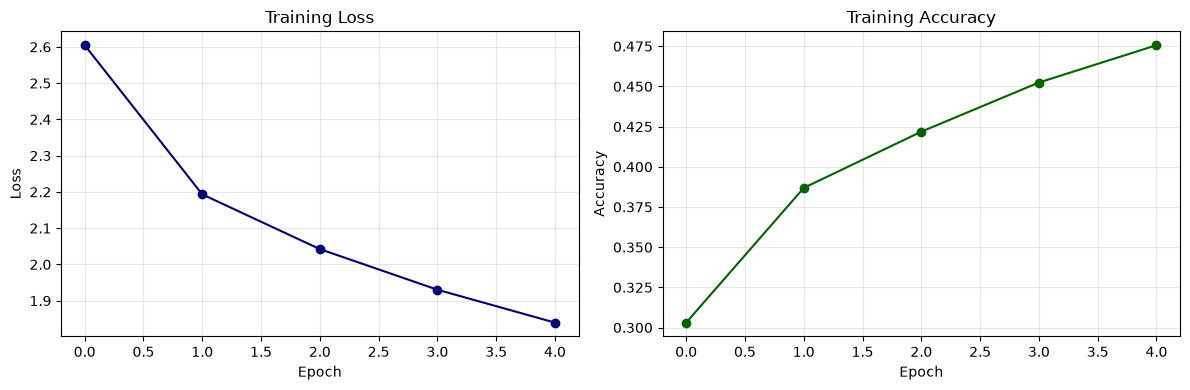

Final training loss: 1.8394
Final training accuracy: 0.4757


In [9]:
# Create graphs for training loss and accuracy

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

# Training loss graph
axes[0].plot(
    history.history["loss"],
    marker="o",
    color="navy"
)

axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

# Training accuracy graph
axes[1].plot(
    history.history["accuracy"],
    marker="o",
    color="darkgreen"
)

axes[1].set_title("Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print final results
print(
    "Final training loss:",
    round(history.history["loss"][-1], 4)
)

print(
    "Final training accuracy:",
    round(history.history["accuracy"][-1], 4)
)

# 10 Create the Text Generation Function

In [10]:
# Function for generating new text

def generate_text(seed, length=400, temperature=0.7):

    # Keep only characters available in the vocabulary
    seed = "".join(
        character
        for character in seed
        if character in char_to_index
    )

    # Use dataset text if the seed becomes empty
    if not seed:
        seed = text[:sequence_length]

    # Keep the final 80 characters
    seed = seed[-sequence_length:]

    # Add spaces if the seed is shorter than 80 characters
    seed = seed.rjust(sequence_length)

    generated_text = seed

    # Generate one character at a time
    for _ in range(length):

        recent_text = generated_text[-sequence_length:]

        input_numbers = np.array([
            [char_to_index[character] for character in recent_text]
        ])

        # Predict probabilities for the next character
        probabilities = model.predict(
            input_numbers,
            verbose=0
        )[0]

        # Apply temperature
        logits = np.log(probabilities + 1e-8)
        logits = logits / temperature

        adjusted_probabilities = np.exp(logits)
        adjusted_probabilities = (
            adjusted_probabilities /
            np.sum(adjusted_probabilities)
        )

        # Select the next character
        next_index = np.random.choice(
            len(vocab),
            p=adjusted_probabilities
        )

        next_character = index_to_char[next_index]

        generated_text += next_character

    return generated_text

# 11 Generate New Text

In [14]:
# Provide a starting sentence

seed_text = (
    "Alice was beginning to wonder "
    "what would happen next"
)

# Generate 500 new characters
generated_story = generate_text(
    seed=seed_text,
    length=500,
    temperature=0.7
)

print("GENERATED STORY:\n")
print(generated_story.lstrip())

GENERATED STORY:

Alice was beginning to wonder what would happen nexte all shere as hare was. “I wat bat think to sack the reas the ig she soudd at one _migh and the Hat was the wat the sad botten, and “you a dourked you know-nother the Hater as she hoom thing and lent a rittle be ans amoon at. “Ot men a of was the wither with it syer wither to the mangen it caster the care sores a muls was hangand ance chigh were stoor grente. “Whe plich, and the it the sulden a the gat the rearky quingo mee not to hay, “On the said at it she yous the ush is it the kinat be a ve


# 12 Practical Application Demonstration

In [13]:
def story_starter(prompt):

    print("USER PROMPT:")
    print(prompt)

    print("\nMODEL-GENERATED CONTINUATION:\n")

    continuation = generate_text(
        seed=prompt,
        length=350,
        temperature=0.65
    )

    # Remove beginning spaces
    print(continuation.lstrip())


# Test the application
story_starter(
    "The little door opened and Alice saw"
)

USER PROMPT:
The little door opened and Alice saw

MODEL-GENERATED CONTINUATION:

The little door opened and Alice saw the Latt the fon to gre couch said the sould buce a litter of she what wit it getten at she waid the Hould ar of ken of wite of the Duched to seat well sither curching and worly was a of a like, and the you know of in don at it wish.” “I’ll she best witt it as her as asare of she Onother the bouther the Houch be to Hatter on thing. “O_ the rattor 


# 13 Conclusion and Ethical Considerations

## Conclusion
This project demonstrated how a character-level LSTM model can be trained to generate text. The model learned character patterns, punctuation, word fragments, and basic writing styles from *Alice's Adventures in Wonderland*. The generated text may contain spelling mistakes or repeated phrases because the model is small and was trained for only five epochs.

## Practical Application

The trained model can be used as a simple story-starter assistant. A user provides a short prompt, and the model produces a possible continuation. A writer can review and edit the generated content.

## Ethical Considerations

Generative AI may produce biased, inaccurate, harmful, or copyrighted content. Public-domain or properly licensed datasets should be used. Personal and confidential information should be protected. Generated content should be reviewed by a person and clearly identified as AI-generated when necessary.

## Future Improvements

The model could be improved by:

- Training for more epochs
- Using a larger licensed dataset
- Adding validation data
- Using dropout and early stopping
- Testing different temperature values
- Replacing the LSTM with a transformer model